# HR Employee Attrition — Dashboard

Notebook นี้อ่านไฟล์ `WA_Fn-UseC_-HR-Employee-Attrition.csv` แล้วสร้าง **หน้า dashboard รวมกราฟ** ในรูปเดียว (KPI + 9 กราฟ) พร้อมบันทึกเป็นไฟล์ PNG

**วิธีใช้**

1. ใช้ไฟล์ CSV ใน `data/raw/` ของ repo ได้เลย (หรือแก้ `CSV_PATH` ใน cell ถัดไป)
2. กด **Run All**
3. ได้ไฟล์ `hr_attrition_dashboard.png` ในโฟลเดอร์เดียวกัน

ใช้แค่ `pandas`, `numpy`, `matplotlib` — ถ้ายังไม่มีให้รัน `pip install pandas numpy matplotlib`

> ข้อความในกราฟมีทั้งภาษาอังกฤษและไทย — ภาษาไทยใช้ฟอนต์ที่มีในเครื่อง (Tahoma / Leelawadee UI บน Windows, Thonburi บน macOS) ถ้าไม่มีจะแสดงเป็นกล่องสี่เหลี่ยม

## 1. ตั้งค่า

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.ticker import FuncFormatter

# ---- แก้ตรงนี้ได้ ----
CSV_PATH = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"   # path relative to this notebook (docs/)
OUTPUT_PNG = "hr_attrition_dashboard.png"            # ชื่อไฟล์รูปที่จะบันทึก
SAVE_DPI = 150                                       # ความละเอียดของไฟล์ PNG

# ---- สีและสไตล์ของ dashboard ----
SURFACE = "#fcfcfb"    # พื้นหลัง
TILE = "#ffffff"       # พื้นการ์ด KPI
INK = "#0b0b0b"        # ตัวหนังสือหลัก
SECONDARY = "#52514e"  # ตัวหนังสือรอง
MUTED = "#898781"      # ป้ายแกน
GRID = "#e1e0d9"       # เส้นกริด
AXIS = "#c3c2b7"       # เส้นฐานแกน
BLUE = "#2a78d6"       # สีหลัก / พนักงานที่ยังอยู่ (Stayed)
ORANGE = "#eb6834"     # พนักงานที่ลาออก (Left)
RED = "#e34948"        # ค่าสหสัมพันธ์เชิงบวก (ลาออกมากขึ้น)
SEQ_BLUES = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # ไล่ระดับสำหรับ heatmap

# ฟอนต์ไทยสำรอง: matplotlib ใช้ DejaVu Sans ก่อน แล้วใช้ฟอนต์ไทยตัวแรกที่มีในเครื่องกับตัวอักษรไทย
THAI_FONTS = ["Tahoma", "Leelawadee UI", "Thonburi", "Noto Sans Thai", "TH Sarabun New"]
_installed = {f.name for f in font_manager.fontManager.ttflist}
FONTS = ["DejaVu Sans"] + [f for f in THAI_FONTS if f in _installed]
if len(FONTS) == 1:
    print("ไม่พบฟอนต์ไทยในเครื่อง — ตัวอักษรไทยในกราฟจะแสดงเป็นกล่องสี่เหลี่ยม")

plt.rcParams.update({
    "font.family": FONTS,
    "font.size": 11,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "text.color": INK,
    "axes.labelcolor": SECONDARY,
})

## 2. โหลดและเตรียมข้อมูล

In [2]:
# ลองหาไฟล์ตาม CSV_PATH ก่อน ถ้าไม่เจอให้ลองโฟลเดอร์เดียวกับ notebook
candidates = [Path(CSV_PATH), Path(Path(CSV_PATH).name)]
csv_file = next((p for p in candidates if p.exists()), None)
if csv_file is None:
    raise FileNotFoundError(
        f"ไม่พบไฟล์ {Path(CSV_PATH).resolve()} — แก้ค่า CSV_PATH ใน cell ตั้งค่า (cwd ตอนนี้: {Path.cwd()})"
    )

df = pd.read_csv(csv_file)
n_rows, n_cols = df.shape

# 1 = ลาออก, 0 = ยังอยู่
df["Left"] = (df["Attrition"] == "Yes").astype(int)
df["OverTimeFlag"] = (df["OverTime"] == "Yes").astype(int)

# จัดกลุ่มช่วงอายุ / อายุงาน / รายได้
df["AgeBand"] = pd.cut(
    df["Age"], bins=[17, 24, 29, 34, 39, 44, 49, 60],
    labels=["18–24", "25–29", "30–34", "35–39", "40–44", "45–49", "50–60"],
)
df["TenureBand"] = pd.cut(
    df["YearsAtCompany"], bins=[-1, 1, 3, 5, 10, 20, 40],
    labels=["0–1", "2–3", "4–5", "6–10", "11–20", "21+"],
)
df["IncomeBand"] = pd.cut(
    df["MonthlyIncome"], bins=[0, 2500, 5000, 7500, 10000, 15000, 20000],
    labels=["≤2.5K", "2.5–5K", "5–7.5K", "7.5–10K", "10–15K", "15–20K"],
)

print(f"โหลดข้อมูล {n_rows:,} แถว, {n_cols} คอลัมน์ | ค่าว่าง: {int(df.isna().sum().sum())}")
df.head()

โหลดข้อมูล 1,470 แถว, 35 คอลัมน์ | ค่าว่าง: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Left,OverTimeFlag,AgeBand,TenureBand,IncomeBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,1,1,40–44,6–10,5–7.5K
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,0,0,45–49,6–10,5–7.5K
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,1,1,35–39,0–1,≤2.5K
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,0,1,30–34,6–10,2.5–5K
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,0,0,25–29,2–3,2.5–5K


## 3. ตัวเลขสรุป (KPI)

In [3]:
def rate_table(col, order=None):
    """อัตราการลาออกแยกตามคอลัมน์ col -> ตาราง n (จำนวนคน), left (ลาออก), rate (%)"""
    t = df.groupby(col, observed=True)["Left"].agg(n="size", left="sum")
    t["rate"] = t["left"] / t["n"] * 100
    if order is not None:
        t = t.reindex(order)
    return t


N = len(df)
N_LEFT = int(df["Left"].sum())
OVERALL = N_LEFT / N * 100

kpis = [
    # (ป้าย, ป้ายภาษาไทย, ค่า, คำอธิบาย)
    ("Attrition rate", "อัตราการลาออก", f"{OVERALL:.1f}%", f"{N_LEFT:,} of {N:,} employees left"),
    ("Employees", "จำนวนพนักงาน", f"{N:,}", f"{df['Department'].nunique()} departments, {df['JobRole'].nunique()} job roles"),
    ("Working overtime", "ทำงานล่วงเวลา", f"{df['OverTimeFlag'].mean() * 100:.1f}%", f"{int(df['OverTimeFlag'].sum()):,} employees"),
    ("Median monthly income", "รายได้ต่อเดือน (มัธยฐาน)", f"${df['MonthlyIncome'].median():,.0f}", f"mean ${df['MonthlyIncome'].mean():,.0f}"),
    ("Median tenure", "อายุงาน (มัธยฐาน)", f"{df['YearsAtCompany'].median():.0f} yrs", f"mean {df['YearsAtCompany'].mean():.1f} yrs at company"),
    ("Median age", "อายุ (มัธยฐาน)", f"{df['Age'].median():.0f}", f"range {df['Age'].min()}–{df['Age'].max()}"),
]
pd.DataFrame(kpis, columns=["KPI", "KPI (TH)", "Value", "Note"])

,KPI,KPI (TH),Value,Note
0,Attrition rate,อัตราการลาออก,16.1%,"237 of 1,470 employees left"
1,Employees,จำนวนพนักงาน,"1,470","3 departments, 9 job roles"
2,Working overtime,ทำงานล่วงเวลา,28.3%,416 employees
3,Median monthly income,รายได้ต่อเดือน (มัธยฐาน),"$4,919","mean $6,503"
4,Median tenure,อายุงาน (มัธยฐาน),5 yrs,mean 7.0 yrs at company
5,Median age,อายุ (มัธยฐาน),36,range 18–60


## 4. ฟังก์ชันวาดกราฟ

In [4]:
def style_axis(ax, title, subtitle=None, grid="x"):
    """สไตล์กลางของทุกกราฟ: ไม่มีกรอบ, กริดบาง, หัวข้อชิดซ้าย"""
    for side in ax.spines:
        ax.spines[side].set_visible(False)
    base = "left" if grid == "x" else "bottom"
    ax.spines[base].set_visible(True)
    ax.spines[base].set_color(AXIS)
    ax.set_axisbelow(True)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
    ax.tick_params(axis="both", length=0, colors=SECONDARY, labelsize=10.5)
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", color=INK,
                 pad=16 + 15 * (subtitle.count("\n") + 1) if subtitle else 12)
    if subtitle:
        ax.text(0, 1.0, subtitle, transform=ax.transAxes, fontsize=10.5,
                color=SECONDARY, va="bottom", ha="left",
                bbox=dict(facecolor="none", edgecolor="none", pad=6))


# พื้นหลังสีเดียวกับ dashboard หลังป้ายตัวเลข เพื่อไม่ให้เส้นอ้างอิงทับตัวหนังสือ
LABEL_BOX = dict(facecolor=SURFACE, edgecolor="none", pad=1.5)


def pct(x, _=None):
    return f"{x:.0f}%"


def overall_line(ax, orient="v"):
    """เส้นอ้างอิง = อัตราการลาออกเฉลี่ยทั้งบริษัท"""
    if orient == "v":
        ax.axvline(OVERALL, color=SECONDARY, linewidth=1, zorder=1)
        ax.text(OVERALL, 0.992, f" Overall · เฉลี่ยรวม {OVERALL:.1f}%", transform=ax.get_xaxis_transform(),
                fontsize=9.5, color=SECONDARY, va="top", ha="left")
    else:
        ax.axhline(OVERALL, color=SECONDARY, linewidth=1, zorder=1)
        ax.text(1.012, OVERALL, f"Overall\nเฉลี่ยรวม\n{OVERALL:.1f}%", transform=ax.get_yaxis_transform(),
                fontsize=9.5, color=SECONDARY, va="center", ha="left")


def hbar_rate(ax, labels, table, title, subtitle, ypos=None):
    """กราฟแท่งแนวนอนของอัตราการลาออก (แท่งบนสุด = รายการแรก)"""
    y = np.arange(len(table))[::-1] if ypos is None else np.asarray(ypos)
    ax.barh(y, table["rate"], height=0.58, color=BLUE, zorder=2)
    for yi, (_, r) in zip(y, table.iterrows()):
        ax.annotate(f"{r['rate']:.1f}%", (r["rate"], yi), xytext=(6, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=10.5, color=INK, fontweight="bold",
                    bbox=LABEL_BOX, zorder=4)
        ax.annotate(f"{int(r['left'])}/{int(r['n'])}", (r["rate"], yi), xytext=(52, 0),
                    textcoords="offset points", va="center", ha="left", fontsize=9, color=MUTED,
                    bbox=LABEL_BOX, zorder=4)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlim(0, max(table["rate"].max() * 1.32, OVERALL * 1.5))
    ax.set_ylim(y.min() - 0.75, y.max() + 1.35)   # เผื่อที่ด้านบนให้ป้าย Overall
    ax.xaxis.set_major_formatter(FuncFormatter(pct))
    style_axis(ax, title, subtitle, grid="x")
    overall_line(ax, "v")


def column_rate(ax, table, title, subtitle, xlabel):
    """กราฟแท่งแนวตั้งของอัตราการลาออกตามช่วง (เรียงลำดับตามช่วง)"""
    x = np.arange(len(table))
    ax.bar(x, table["rate"], width=0.55, color=BLUE, zorder=2)
    for xi, (_, r) in zip(x, table.iterrows()):
        ax.annotate(f"{r['rate']:.1f}%", (xi, r["rate"]), xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10.5, color=INK, fontweight="bold",
                    bbox=LABEL_BOX, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{idx}\nn={int(n)}" for idx, n in zip(table.index, table["n"])])
    ax.set_xlabel(xlabel, fontsize=10.5, labelpad=8)
    ax.set_ylim(0, table["rate"].max() * 1.2)
    ax.yaxis.set_major_formatter(FuncFormatter(pct))
    style_axis(ax, title, subtitle, grid="y")
    overall_line(ax, "h")


def draw_kpis(ax):
    """แถวการ์ด KPI — ใบแรก (อัตราการลาออก) เป็นตัวเลขนำ ขนาดใหญ่กว่าใบอื่น"""
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    widths = np.array([1.5] + [1.0] * (len(kpis) - 1))
    gap = 0.012
    unit = (1 - gap * (len(kpis) - 1)) / widths.sum()
    x = 0.0
    for i, ((label, label_th, value, note), w) in enumerate(zip(kpis, widths)):
        width = w * unit
        ax.add_patch(FancyBboxPatch(
            (x, 0.04), width, 0.92, boxstyle="round,pad=0,rounding_size=0.012",
            facecolor=TILE, edgecolor=GRID, linewidth=1, transform=ax.transAxes, clip_on=False,
        ))
        ax.text(x + 0.014, 0.84, label, fontsize=11.5, color=SECONDARY, va="center")
        ax.text(x + 0.014, 0.69, label_th, fontsize=10.5, color=SECONDARY, va="center")
        ax.text(x + 0.014, 0.44, value, fontsize=40 if i == 0 else 27, color=INK,
                fontweight="bold", va="center")
        ax.text(x + 0.014, 0.15, note, fontsize=10, color=MUTED, va="center")
        x += width + gap

## 5. สร้าง dashboard

บันทึกแล้ว: hr_attrition_dashboard.png


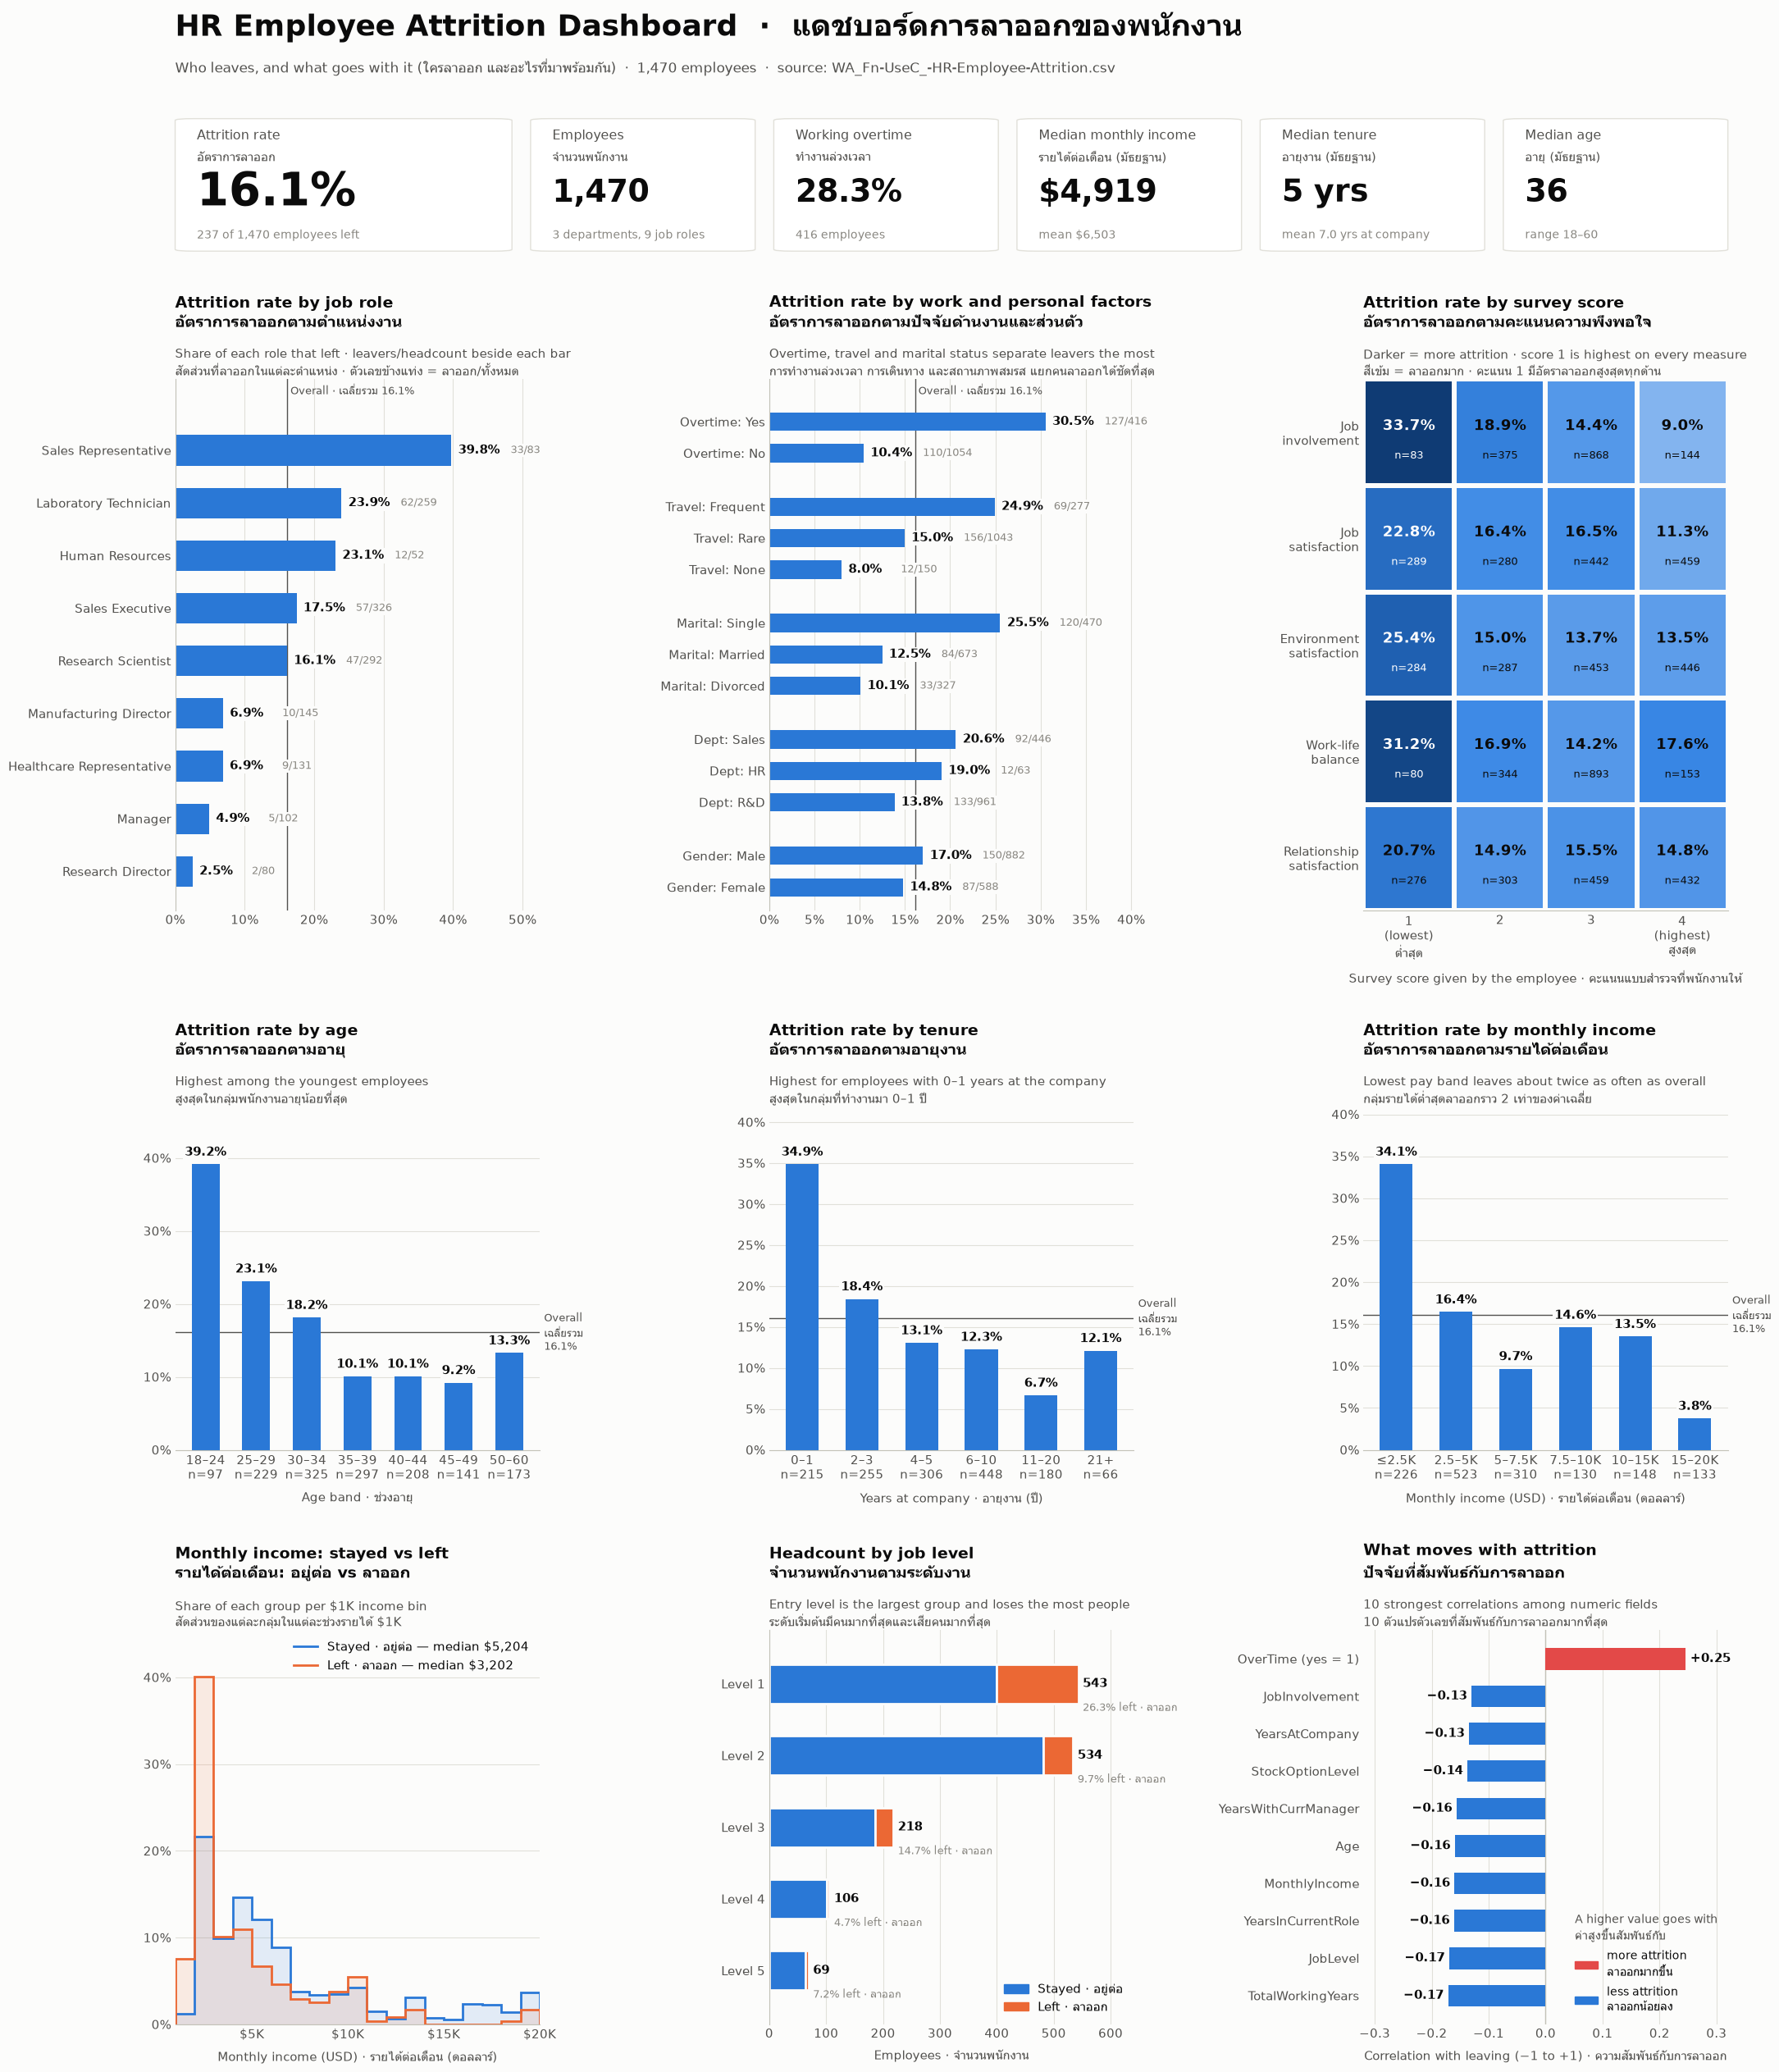

In [5]:
fig = plt.figure(figsize=(22, 25.5), layout="constrained")
fig.get_layout_engine().set(w_pad=0.25, h_pad=0.22, wspace=0.05, hspace=0.05)
gs = GridSpec(5, 3, figure=fig, height_ratios=[0.20, 0.42, 1.55, 1.0, 1.15])

# ---------- หัวเรื่อง ----------
ax = fig.add_subplot(gs[0, :])
ax.set_axis_off()
ax.text(0, 0.72, "HR Employee Attrition Dashboard  ·  แดชบอร์ดการลาออกของพนักงาน", fontsize=26, fontweight="bold",
        color=INK, va="center", transform=ax.transAxes)
ax.text(0, 0.14, f"Who leaves, and what goes with it (ใครลาออก และอะไรที่มาพร้อมกัน)  ·  {N:,} employees  ·  source: {csv_file.name}",
        fontsize=12.5, color=SECONDARY, va="center", transform=ax.transAxes)

# ---------- KPI ----------
draw_kpis(fig.add_subplot(gs[1, :]))

# ---------- แถว 1 ----------
# (1) อัตราการลาออกตามตำแหน่งงาน
t_role = rate_table("JobRole").sort_values("rate", ascending=False)
hbar_rate(fig.add_subplot(gs[2, 0]), t_role.index, t_role,
          "Attrition rate by job role\nอัตราการลาออกตามตำแหน่งงาน",
          "Share of each role that left · leavers/headcount beside each bar\nสัดส่วนที่ลาออกในแต่ละตำแหน่ง · ตัวเลขข้างแท่ง = ลาออก/ทั้งหมด")

# (2) อัตราการลาออกตามปัจจัยการทำงานและส่วนตัว
factor_groups = [
    ("Overtime", "OverTime", {"Yes": "Yes", "No": "No"}),
    ("Travel", "BusinessTravel", {"Travel_Frequently": "Frequent", "Travel_Rarely": "Rare", "Non-Travel": "None"}),
    ("Marital", "MaritalStatus", {"Single": "Single", "Married": "Married", "Divorced": "Divorced"}),
    ("Dept", "Department", {"Sales": "Sales", "Human Resources": "HR", "Research & Development": "R&D"}),
    ("Gender", "Gender", {"Male": "Male", "Female": "Female"}),
]
parts, f_labels, f_y, y_cursor = [], [], [], 0.0
for name, col, mapping in factor_groups:
    t = rate_table(col, order=list(mapping))
    parts.append(t)
    for key in mapping:
        f_labels.append(f"{name}: {mapping[key]}")
        f_y.append(y_cursor)
        y_cursor -= 1.0
    y_cursor -= 0.7          # เว้นช่องระหว่างกลุ่ม
t_factor = pd.concat(parts)
hbar_rate(fig.add_subplot(gs[2, 1]), f_labels, t_factor,
          "Attrition rate by work and personal factors\nอัตราการลาออกตามปัจจัยด้านงานและส่วนตัว",
          "Overtime, travel and marital status separate leavers the most\nการทำงานล่วงเวลา การเดินทาง และสถานภาพสมรส แยกคนลาออกได้ชัดที่สุด", ypos=f_y)

# (3) heatmap: อัตราการลาออกตามคะแนนความพึงพอใจ
sat_cols = {
    "Job involvement": "JobInvolvement",
    "Job satisfaction": "JobSatisfaction",
    "Environment satisfaction": "EnvironmentSatisfaction",
    "Work-life balance": "WorkLifeBalance",
    "Relationship satisfaction": "RelationshipSatisfaction",
}
heat = pd.DataFrame({name: rate_table(col)["rate"] for name, col in sat_cols.items()}).T[[1, 2, 3, 4]]
heat_n = pd.DataFrame({name: rate_table(col)["n"] for name, col in sat_cols.items()}).T[[1, 2, 3, 4]]
ax = fig.add_subplot(gs[2, 2])
cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUES)
vmax = float(np.ceil(heat.values.max() / 5) * 5)
ax.pcolormesh(heat.values, cmap=cmap, vmin=0, vmax=vmax, edgecolors=SURFACE, linewidth=3)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        r_, g_, b_ = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
                      for c in cmap(v / vmax)[:3]]
        lum = 0.2126 * r_ + 0.7152 * g_ + 0.0722 * b_
        txt = "#ffffff" if 1.05 / (lum + 0.05) > (lum + 0.05) / 0.05 else INK   # เลือกสีที่ contrast ดีกว่า
        ax.text(j + 0.5, i + 0.44, f"{v:.1f}%", ha="center", va="center", fontsize=13,
                fontweight="bold", color=txt)
        ax.text(j + 0.5, i + 0.72, f"n={int(heat_n.values[i, j])}", ha="center", va="center",
                fontsize=9, color=txt)
ax.set_xticks(np.arange(4) + 0.5)
ax.set_xticklabels(["1\n(lowest)\nต่ำสุด", "2", "3", "4\n(highest)\nสูงสุด"])
ax.set_yticks(np.arange(len(heat)) + 0.5)
ax.set_yticklabels([s.replace(" ", "\n", 1) for s in heat.index])
ax.invert_yaxis()
ax.set_xlabel("Survey score given by the employee · คะแนนแบบสำรวจที่พนักงานให้", fontsize=10.5, labelpad=8)
style_axis(ax, "Attrition rate by survey score\nอัตราการลาออกตามคะแนนความพึงพอใจ",
           "Darker = more attrition · score 1 is highest on every measure\nสีเข้ม = ลาออกมาก · คะแนน 1 มีอัตราลาออกสูงสุดทุกด้าน", grid=None)
ax.spines["left"].set_visible(False)

# ---------- แถว 2 ----------
column_rate(fig.add_subplot(gs[3, 0]), rate_table("AgeBand"),
            "Attrition rate by age\nอัตราการลาออกตามอายุ",
            "Highest among the youngest employees\nสูงสุดในกลุ่มพนักงานอายุน้อยที่สุด", "Age band · ช่วงอายุ")
column_rate(fig.add_subplot(gs[3, 1]), rate_table("TenureBand"),
            "Attrition rate by tenure\nอัตราการลาออกตามอายุงาน",
            "Highest for employees with 0–1 years at the company\nสูงสุดในกลุ่มที่ทำงานมา 0–1 ปี",
            "Years at company · อายุงาน (ปี)")
column_rate(fig.add_subplot(gs[3, 2]), rate_table("IncomeBand"),
            "Attrition rate by monthly income\nอัตราการลาออกตามรายได้ต่อเดือน",
            "Lowest pay band leaves about twice as often as overall\nกลุ่มรายได้ต่ำสุดลาออกราว 2 เท่าของค่าเฉลี่ย",
            "Monthly income (USD) · รายได้ต่อเดือน (ดอลลาร์)")

# ---------- แถว 3 ----------
# (7) การกระจายรายได้: อยู่ต่อ vs ลาออก
ax = fig.add_subplot(gs[4, 0])
bins = np.arange(1000, 20001, 1000)
for flag, color, name in [(0, BLUE, "Stayed · อยู่ต่อ"), (1, ORANGE, "Left · ลาออก")]:
    vals = df.loc[df["Left"] == flag, "MonthlyIncome"]
    share, _ = np.histogram(vals, bins=bins)
    share = share / len(vals) * 100
    ax.stairs(share, bins, fill=True, color=color, alpha=0.12, zorder=2)
    ax.stairs(share, bins, color=color, linewidth=2, zorder=3,
              label=f"{name} — median ${vals.median():,.0f}")
ax.set_xlim(1000, 20000)
ax.set_xticks([5000, 10000, 15000, 20000])
ax.set_ylim(0, ax.get_ylim()[1] * 1.08)
ax.set_xlabel("Monthly income (USD) · รายได้ต่อเดือน (ดอลลาร์)", fontsize=10.5, labelpad=8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v / 1000:.0f}K"))
ax.yaxis.set_major_formatter(FuncFormatter(pct))
style_axis(ax, "Monthly income: stayed vs left\nรายได้ต่อเดือน: อยู่ต่อ vs ลาออก",
           "Share of each group per $1K income bin\nสัดส่วนของแต่ละกลุ่มในแต่ละช่วงรายได้ $1K", grid="y")
ax.legend(frameon=False, fontsize=10.5, loc="upper right", labelcolor=INK)

# (8) จำนวนพนักงานตามระดับงาน แยก อยู่ต่อ / ลาออก
ax = fig.add_subplot(gs[4, 1])
lvl = df.groupby(["JobLevel", "Left"]).size().unstack(fill_value=0).sort_index()
y = np.arange(len(lvl))[::-1]
ax.barh(y, lvl[0], height=0.55, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=2)
ax.barh(y, lvl[1], left=lvl[0], height=0.55, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=2)
for yi, (_, r) in zip(y, lvl.iterrows()):
    total = r[0] + r[1]
    ax.text(total + 8, yi, f"{int(total):,}", va="center", ha="left", fontsize=10.5,
            color=INK, fontweight="bold")
    ax.text(total + 8, yi - 0.33, f"{r[1] / total * 100:.1f}% left · ลาออก", va="center", ha="left",
            fontsize=9, color=MUTED)
ax.set_yticks(y)
ax.set_yticklabels([f"Level {i}" for i in lvl.index])
ax.set_xlim(0, lvl.sum(axis=1).max() * 1.18)
ax.set_ylim(y.min() - 0.75, y.max() + 0.75)
ax.set_xlabel("Employees · จำนวนพนักงาน", fontsize=10.5, labelpad=8)
style_axis(ax, "Headcount by job level\nจำนวนพนักงานตามระดับงาน",
           "Entry level is the largest group and loses the most people\nระดับเริ่มต้นมีคนมากที่สุดและเสียคนมากที่สุด", grid="x")
ax.legend(handles=[Patch(color=BLUE, label="Stayed · อยู่ต่อ"), Patch(color=ORANGE, label="Left · ลาออก")],
          frameon=False, fontsize=10.5, loc="lower right", labelcolor=INK)

# (9) สหสัมพันธ์ของตัวแปรตัวเลขกับการลาออก
ax = fig.add_subplot(gs[4, 2])
skip = {"Left", "EmployeeCount", "StandardHours", "EmployeeNumber"}
num_cols = [c for c in df.select_dtypes("number").columns if c not in skip]
corr = df[num_cols].corrwith(df["Left"]).rename({"OverTimeFlag": "OverTime (yes = 1)"})
corr = corr.reindex(corr.abs().sort_values(ascending=False).index[:10]).sort_values()
y = np.arange(len(corr))
ax.barh(y, corr.values, height=0.58, color=[RED if v > 0 else BLUE for v in corr.values], zorder=2)
ax.axvline(0, color=AXIS, linewidth=1, zorder=1)
for yi, v in zip(y, corr.values):
    ax.text(v + (0.008 if v > 0 else -0.008), yi, f"{v:+.2f}".replace("-", "−"), va="center",
            ha="left" if v > 0 else "right", fontsize=10.5, color=INK, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(corr.index)
lim = float(np.abs(corr.values).max()) * 1.3
ax.set_xlim(-lim, lim)
ax.set_xlabel("Correlation with leaving (−1 to +1) · ความสัมพันธ์กับการลาออก", fontsize=10.5, labelpad=8)
style_axis(ax, "What moves with attrition\nปัจจัยที่สัมพันธ์กับการลาออก",
           "10 strongest correlations among numeric fields\n10 ตัวแปรตัวเลขที่สัมพันธ์กับการลาออกมากที่สุด", grid="x")
ax.spines["left"].set_visible(False)
leg = ax.legend(handles=[Patch(color=RED, label="more attrition\nลาออกมากขึ้น"), Patch(color=BLUE, label="less attrition\nลาออกน้อยลง")],
                title="A higher value goes with\nค่าสูงขึ้นสัมพันธ์กับ", frameon=False, fontsize=10, title_fontsize=10,
                loc="lower right", labelcolor=INK, alignment="left")
leg.get_title().set_color(SECONDARY)

fig.savefig(OUTPUT_PNG, dpi=SAVE_DPI)
print(f"บันทึกแล้ว: {OUTPUT_PNG}")
plt.show()

## 6. ตารางตัวเลขเบื้องหลังกราฟ

ตัวเลขชุดเดียวกับที่ใช้วาดกราฟ เผื่อต้องการดูค่าจริงหรือคัดลอกไปใช้ต่อ (`n` = จำนวนพนักงาน, `left` = จำนวนที่ลาออก, `rate` = อัตราการลาออก %)

In [6]:
dimensions = {
    "Job role": t_role,
    "Work & personal factors": t_factor.set_axis(f_labels),
    "Age band": rate_table("AgeBand"),
    "Tenure band (years)": rate_table("TenureBand"),
    "Monthly income band": rate_table("IncomeBand"),
    "Job level": rate_table("JobLevel"),
}
summary = pd.concat(dimensions, names=["Dimension", "Group"]).round({"rate": 1})
summary

n  left  rate
Dimension               Group                                      
Job role                Sales Representative         83    33  39.8
                        Laboratory Technician       259    62  23.9
                        Human Resources              52    12  23.1
                        Sales Executive             326    57  17.5
                        Research Scientist          292    47  16.1
                        Manufacturing Director      145    10   6.9
                        Healthcare Representative   131     9   6.9
                        Manager                     102     5   4.9
                        Research Director            80     2   2.5
Work & personal factors Overtime: Yes               416   127  30.5
                        Overtime: No               1054   110  10.4
                        Travel: Frequent            277    69  24.9
                        Travel: Rare               1043   156  15.0
                        Travel: None                150    12   8.0
                        Marital: Single             470   120  25.5
                        Marital: Married            673    84  12.5
                        Marital: Divorced           327    33  10.1
                        Dept: Sales                 446    92  20.6
                        Dept: HR                     63    12  19.0
                        Dept: R&D                   961   133  13.8
                        Gender: Male                882   150  17.0
                        Gender: Female              588    87  14.8
Age band                18–24                        97    38  39.2
                        25–29                       229    53  23.1
                        30–34                       325    59  18.2
                        35–39                       297    30  10.1
                        40–44                       208    21  10.1
                        45–49                       141    13   9.2
                        50–60                       173    23  13.3
Tenure band (years)     0–1                         215    75  34.9
                        2–3                         255    47  18.4
                        4–5                         306    40  13.1
                        6–10                        448    55  12.3
                        11–20                       180    12   6.7
                        21+                          66     8  12.1
Monthly income band     ≤2.5K                       226    77  34.1
                        2.5–5K                      523    86  16.4
                        5–7.5K                      310    30   9.7
                        7.5–10K                     130    19  14.6
                        10–15K                      148    20  13.5
                        15–20K                      133     5   3.8
Job level               1                           543   143  26.3
                        2                           534    52   9.7
                        3                           218    32  14.7
                        4                           106     5   4.7
                        5                            69     5   7.2

In [7]:
# อัตราการลาออก (%) ตามคะแนนความพึงพอใจ และค่าสหสัมพันธ์กับการลาออก
display(heat.round(1).rename_axis("Attrition rate % by score"))
corr.sort_values(key=abs, ascending=False).round(3).to_frame("Correlation with leaving")

,1,2,3,4
Attrition rate % by score,,,,
Job involvement,33.7,18.9,14.4,9.0
Job satisfaction,22.8,16.4,16.5,11.3
Environment satisfaction,25.4,15.0,13.7,13.5
Work-life balance,31.2,16.9,14.2,17.6
Relationship satisfaction,20.7,14.9,15.5,14.8


,Correlation with leaving
OverTime (yes = 1),0.246
TotalWorkingYears,-0.171
JobLevel,-0.169
YearsInCurrentRole,-0.161
MonthlyIncome,-0.160
Age,-0.159
YearsWithCurrManager,-0.156
StockOptionLevel,-0.137
YearsAtCompany,-0.134
JobInvolvement,-0.130
